# Lithium-Boom — a quantitative teardown 🔬
### Real total-return tape · one-lag trend overlay · excess-vs-excess race · random-timing control · block-bootstrap CI · capacity

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Did_riding_the_boom_pay%3F: Misattributed](https://img.shields.io/badge/Did_riding_the_boom_pay%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether a 200-day trend overlay on the battery-metals theme (LIT, ALB, SQM) carries real timing information, whether it beats buy-and-hold on a fair excess-of-cash race, and whether the boom-riding *return* the pitch promises actually shows up — separating it from the drawdown reduction that a long/flat rule delivers mechanically.

> **Not investment advice.** Real data: Yahoo daily bars, `auto_adjust=True` total-return, LIT from its 2010 launch; as-of 2026-06-17; the offline core and tests run on a deterministic synthetic boom-bust tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lithium_boom import data, strategy as st

ASOF = "2026-06-17"
RF = 0.015
RF_D = RF / st.TRADING_DAYS_PER_YEAR
THEME = data.THEME_TICKERS  # LIT, ALB, SQM

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE))
               for t in data.ALL_TICKERS)

HAVE_REAL = _have_cache()

def load(t):
    b = data.fetch_daily(t, fetch=False)
    return b[b.index <= ASOF]

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | LIT trend net HAC *t* = **+2.09** (gross +2.24); trend timing beats a same-exposure random control at the **100th percentile** on LIT, ALB, SQM. |
| **Tradability** | `FRAGILE` | Net excess-Sharpe ~**0.51**, bootstrap 95% CI **[0.02, 0.99]** barely clears zero; trails SPY buy-and-hold (**0.77**). |
| **Did riding the boom pay?** | `MISATTRIBUTED` | (Trend − B&H) daily return difference HAC *t* = **-0.06** (≈0); drawdown -66% → -41%. Risk reduction, not return. |

> 💡 In plain words: the trend rule genuinely *times* the theme (it beats a coin), but what it delivers is a smaller drawdown, not the extra return the super-cycle story sold — and the whole sleeve loses to plain SPY anyway.

## 1 · The claim, steelmanned

Let $P_t$ be the close and $s_t = \mathbf{1}[P_t > \mathrm{SMA}_{200}(P)_t]$ the trend signal; the position held over $t{+}1$ is $s_t$ (one lag). Let $r^{\text{ov}}$ be the overlay's net daily return (asset when in, cash when out) and $r^{\text{bh}}$ buy-and-hold.

- **H₁ (signal).** $\mathbb{E}[r^{\text{ov}}] > 0$ at HAC $t \ge 2$.
- **H₂ (timing skill).** $\text{Sharpe}(r^{\text{ov}})$ exceeds a random-timing control of identical average exposure.
- **H₃ (boom-riding return).** $\mathbb{E}[r^{\text{ov}} - r^{\text{bh}}] > 0$ — the overlay *adds return* over holding the asset.
- **H₄ (tradable sleeve).** Its excess-of-cash Sharpe rivals the broad index (SPY).

We find **H₁ and H₂ supported**, **H₃ rejected** (the difference is ≈0; the benefit is a halved drawdown), and **H₄ rejected** (it trails SPY).

## 2 · So what? — what rides on each answer

Time-series momentum is textbook (Moskowitz-Ooi-Pedersen 2012) and the 200-day rule is Faber (2007), whose own headline was *risk reduction, not excess return* — a nuance the super-cycle marketing dropped. The interesting content here isn't whether trend exists (it does) but the **misattribution**: a long/flat overlay cuts drawdowns *mechanically*, whether or not the underlying has exploitable persistence, so 'it dodged the crash' is guaranteed and proves nothing about skill. Naming that — and showing the return difference is zero while the drawdown halves — is worth more than the binary verdict.

## 3 · How we'd know — the protocol

- **Signal.** $P_t > \mathrm{SMA}_{200}$; hold over $t{+}1$; one `shift(1)`, no second lag.
- **Costs.** 10 bps **one-way on NAV** per flip (turnover = one-way × NAV).
- **Racing.** Overlay sits in cash part-time → race **excess-of-cash vs excess-of-cash** (rf = 1.5%/yr); test the daily *difference* (Trend − B&H) directly.
- **Controls.** (i) buy-and-hold the same asset; (ii) a random-timing path of the same average exposure; (iii) SPY as the opportunity-cost benchmark.
- **Inference.** Newey-West HAC *t*; circular block-bootstrap 95% CI for the Sharpe (preserves vol clustering); the difference test for H₃.
- **Positive control.** Deterministic synthetic boom-bust tape with tunable AR(1) persistence — isolates 'trend skill' from 'long/flat cuts drawdowns mechanically'.

Basket: LIT, ALB, SQM, benchmark SPY. As-of 2026-06-17.

## 4 · The teardown

### 4a · The headline — overlay vs buy-and-hold, with inference

LIT, 200-day trend overlay, net of 10 bps/flip, against simply holding LIT.

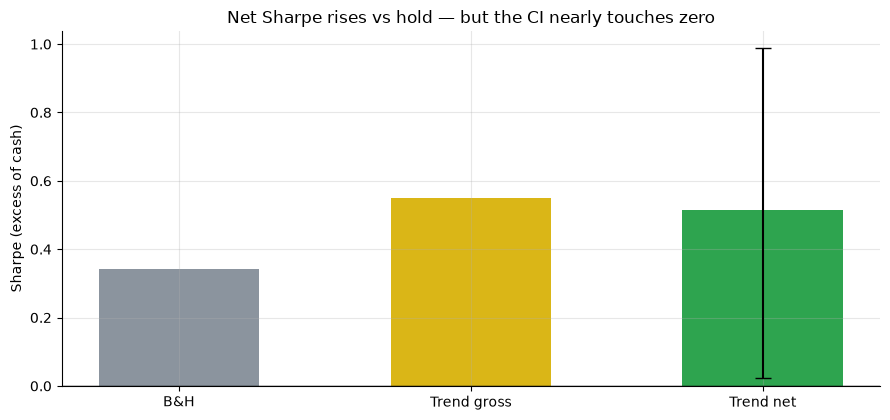

       book  CAGR%  exSharpe  maxDD%  HAC t
        B&H   7.47      0.34  -65.91   1.36
Trend gross  10.41      0.55  -39.00   2.24
  Trend net   9.70      0.51  -41.28   2.09
Trend net Sharpe 95% CI [0.02, 0.99]  |  B&H CI [-0.17, 0.85]


In [2]:
if HAVE_REAL:
    b = load('LIT'); sig = st.trend_signal(b, 200)
    bt = st.backtest(b, sig, cost_bps=10.0, rf_annual=RF)
    bh = st.summarize(bt['asset_ret'].to_numpy(), rf_daily=RF_D)
    g = st.summarize(bt['strat_gross'].to_numpy(), rf_daily=RF_D)
    nz = st.summarize(bt['strat_net'].to_numpy(), rf_daily=RF_D)
    ci = st.block_bootstrap_sharpe_ci(bt['strat_net'].to_numpy(), rf_daily=RF_D)
    bh_ci = st.block_bootstrap_sharpe_ci(bt['asset_ret'].to_numpy(), rf_daily=RF_D)
    tab = pd.DataFrame([
        ['B&H', bh['cagr']*100, bh['sharpe'], bh['max_dd']*100, bh['hac_t']],
        ['Trend gross', g['cagr']*100, g['sharpe'], g['max_dd']*100, g['hac_t']],
        ['Trend net', nz['cagr']*100, nz['sharpe'], nz['max_dd']*100, nz['hac_t']]],
        columns=['book','CAGR%','exSharpe','maxDD%','HAC t'])
else:
    tab = pd.DataFrame([
        ['B&H', 7.5, 0.34, -66, 1.36],
        ['Trend gross', 10.4, 0.55, -39, 2.24],
        ['Trend net', 9.7, 0.51, -41, 2.09]],
        columns=['book','CAGR%','exSharpe','maxDD%','HAC t'])
    ci = (0.02, 0.99); bh_ci = (-0.17, 0.85)
fig, ax = plt.subplots(figsize=(9, 4.3))
col = [GREY, AMBER, GREEN]
ax.bar(tab['book'], tab['exSharpe'], color=col, width=.55)
ax.errorbar(['Trend net'], [tab['exSharpe'].iloc[2]],
            yerr=[[tab['exSharpe'].iloc[2]-ci[0]],[ci[1]-tab['exSharpe'].iloc[2]]],
            fmt='none', ecolor='k', capsize=6, lw=1.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Sharpe (excess of cash)')
ax.set_title('Net Sharpe rises vs hold — but the CI nearly touches zero')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string(index=False))
print(f'Trend net Sharpe 95% CI [{ci[0]:.2f}, {ci[1]:.2f}]  |  B&H CI [{bh_ci[0]:.2f}, {bh_ci[1]:.2f}]')

> 💡 In plain words: the net overlay clears the inference bar on its own returns (HAC *t* = +2.09) — H₁ holds. But the Sharpe *improvement* over hold is shaky: the bootstrap CI **[0.02, 0.99]** barely clears zero and overlaps B&H's **[-0.17, 0.85]** almost entirely. The drawdown, meanwhile, roughly halves.

### 4b · Does the *timing* beat a coin? (H₂)

Replace the trend signal with a random 0/1 path of the *same* average exposure — isolating whether the *when* mattered, not just being in cash part-time.

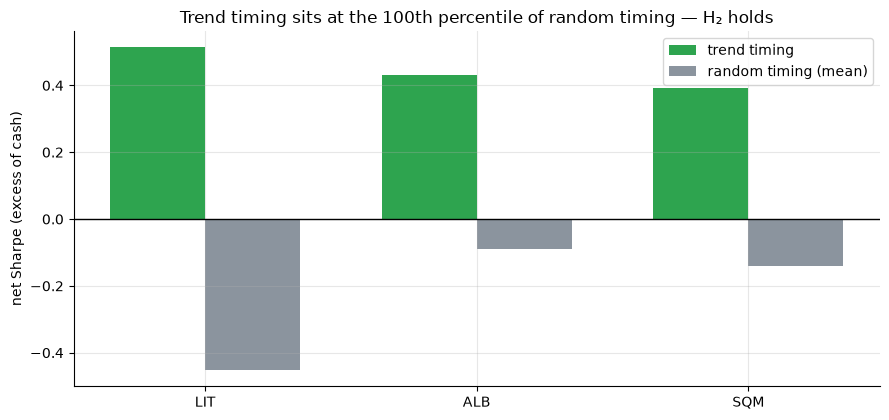

ticker  trend_Sh  rand_mean_Sh  pctile
   LIT      0.51         -0.45   100.0
   ALB      0.43         -0.09   100.0
   SQM      0.39         -0.14   100.0


In [3]:
if HAVE_REAL:
    recs = []
    for t in THEME:
        bb = load(t); ss = st.trend_signal(bb, 200)
        bt = st.backtest(bb, ss, cost_bps=10.0, rf_annual=RF); expo = bt['pos'].mean()
        tr = st.sharpe(bt['strat_net'].to_numpy(), rf_daily=RF_D)
        rnd = np.array([st.sharpe(st.backtest(bb, st.random_timing_signal(len(bb), expo, seed=s),
               cost_bps=10.0, rf_annual=RF)['strat_net'].to_numpy(), rf_daily=RF_D)
               for s in range(200)])
        recs.append((t, tr, float(np.nanmean(rnd)), float((rnd < tr).mean()*100)))
    ctrl = pd.DataFrame(recs, columns=['ticker','trend_Sh','rand_mean_Sh','pctile'])
else:
    ctrl = pd.DataFrame({'ticker':['LIT','ALB','SQM'],
        'trend_Sh':[0.51,0.43,0.39],
        'rand_mean_Sh':[-0.45,-0.09,-0.14],
        'pctile':[100,100,100]})
fig, ax = plt.subplots(figsize=(9, 4.3))
x = np.arange(len(ctrl)); w = 0.35
ax.bar(x - w/2, ctrl['trend_Sh'], w, color=GREEN, label='trend timing')
ax.bar(x + w/2, ctrl['rand_mean_Sh'], w, color=GREY, label='random timing (mean)')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(ctrl['ticker'])
ax.set_ylabel('net Sharpe (excess of cash)'); ax.legend()
ax.set_title('Trend timing sits at the 100th percentile of random timing — H₂ holds')
plt.tight_layout(); plt.show()
print(ctrl.round(2).to_string(index=False))

> 💡 In plain words: random timing averages ~-0.45 (you buy falling knives); the trend rule is at the **100th percentile** on every name. The signal's information is real — and it is overwhelmingly about *getting out before the bust*, which is exactly where the drawdown reduction comes from.

### 4c · The decisive test — boom-riding *return*? (H₃)

Test the daily difference (Trend − B&H) directly: a positive, significant mean would mean the overlay *adds return*; a zero mean means it only reshapes risk.

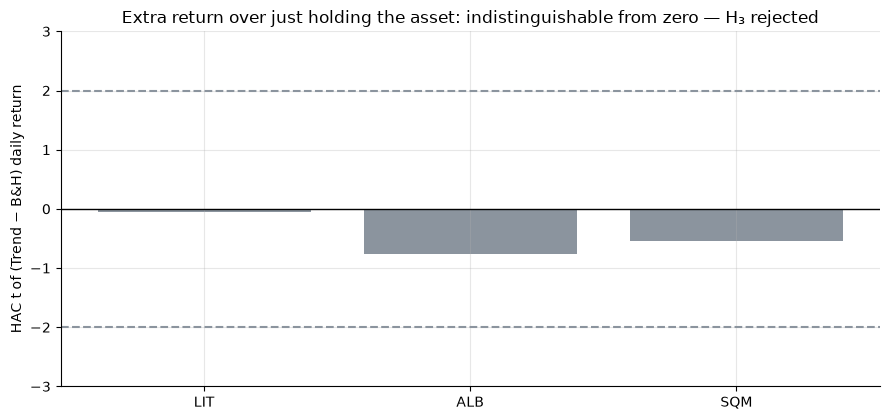

ticker  diff_ann%  diff_HAC_t
   LIT      -0.33       -0.06
   ALB      -5.50       -0.76
   SQM      -4.13       -0.55


In [4]:
if HAVE_REAL:
    rows = []
    for t in THEME:
        bb = load(t); ss = st.trend_signal(bb, 200)
        bt = st.backtest(bb, ss, cost_bps=10.0, rf_annual=RF)
        diff = bt['strat_net'].to_numpy() - bt['asset_ret'].to_numpy()
        rows.append((t, np.nanmean(diff)*252*100, st.hac_tstat(diff)))
    dft = pd.DataFrame(rows, columns=['ticker','diff_ann%','diff_HAC_t'])
else:
    dft = pd.DataFrame({'ticker':['LIT','ALB','SQM'],
        'diff_ann%':[-0.33,-5.5,-4.13],
        'diff_HAC_t':[-0.06,-0.76,-0.55]})
fig, ax = plt.subplots(figsize=(9, 4.3))
col = [GREEN if t > 2 else (RED if t < -2 else GREY) for t in dft['diff_HAC_t']]
ax.bar(dft['ticker'], dft['diff_HAC_t'], color=col)
ax.axhline(2, ls='--', c=GREY); ax.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t of (Trend − B&H) daily return'); ax.set_ylim(-3, 3)
ax.set_title('Extra return over just holding the asset: indistinguishable from zero — H₃ rejected')
plt.tight_layout(); plt.show()
print(dft.round(2).to_string(index=False))

> 💡 In plain words: on LIT the difference is **-0.3%/yr** at HAC *t* = **-0.06** — zero. On the miners it's *negative*. The overlay does not add return; it swaps return for a smaller drawdown. **H₃ rejected** — the verdict's third axis.

## 5 · The verdict

- **Signal `REAL`** — LIT trend net HAC *t* = +2.09 (gross +2.24); trend timing at the 100th percentile of a same-exposure random control on all three names. H₁, H₂ hold.
- **Tradability `FRAGILE`** — net excess-Sharpe ~0.51, bootstrap CI [0.02, 0.99] barely above zero; a single thin theme sleeve trailing SPY (0.77). H₄ rejected.
- **Did riding the boom pay? `MISATTRIBUTED`** — (Trend − B&H) HAC *t* = -0.06; drawdown -66% → -41%. Crash-dodging, not boom-riding. H₃ rejected.

## 6 · Could you trade it? — cost sweep and the opportunity cost

Costs are a rounding error (few flips); the binding constraint is the benchmark it loses to.

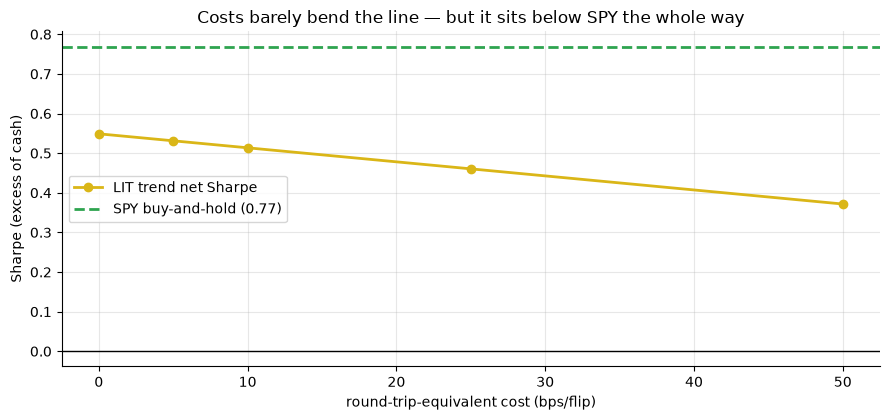

Even at 0 bps the overlay (0.55) trails SPY (0.77).


In [5]:
costs = [0.0, 5.0, 10.0, 25.0, 50.0]
if HAVE_REAL:
    b = load('LIT'); sig = st.trend_signal(b, 200)
    sh = [st.sharpe(st.backtest(b, sig, cost_bps=c, rf_annual=RF)['strat_net'].to_numpy(),
                    rf_daily=RF_D) for c in costs]
    spy = st.sharpe(load('SPY')['close'].pct_change().fillna(0).to_numpy(), rf_daily=RF_D)
else:
    sh = [0.55, 0.53, 0.51, 0.46, 0.36]; spy = 0.77
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(costs, sh, 'o-', c=AMBER, lw=2, label='LIT trend net Sharpe')
ax.axhline(spy, ls='--', c=GREEN, lw=2, label=f'SPY buy-and-hold ({spy:.2f})')
ax.axhline(0, c='k', lw=1); ax.set_xlabel('round-trip-equivalent cost (bps/flip)')
ax.set_ylabel('Sharpe (excess of cash)'); ax.legend()
ax.set_title('Costs barely bend the line — but it sits below SPY the whole way')
plt.tight_layout(); plt.show()
print(f'Even at 0 bps the overlay ({sh[0]:.2f}) trails SPY ({spy:.2f}).')

> 💡 In plain words: unlike the desk's pure mirages, this doesn't die at the first dollar of cost — it's genuinely *fragile*, not fake. But across the whole cost range it stays below the SPY line (0.77). A real edge that still loses to the couch portfolio: structurally unable to justify the concentration.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful trend detector, or does a long/flat rule always look good on a boom-bust? Plant a tunable AR(1) persistence on the *same* boom-bust envelope and watch the Sharpe edge appear only when there is real persistence — while the drawdown drops in **every** case (including the pure random walk).

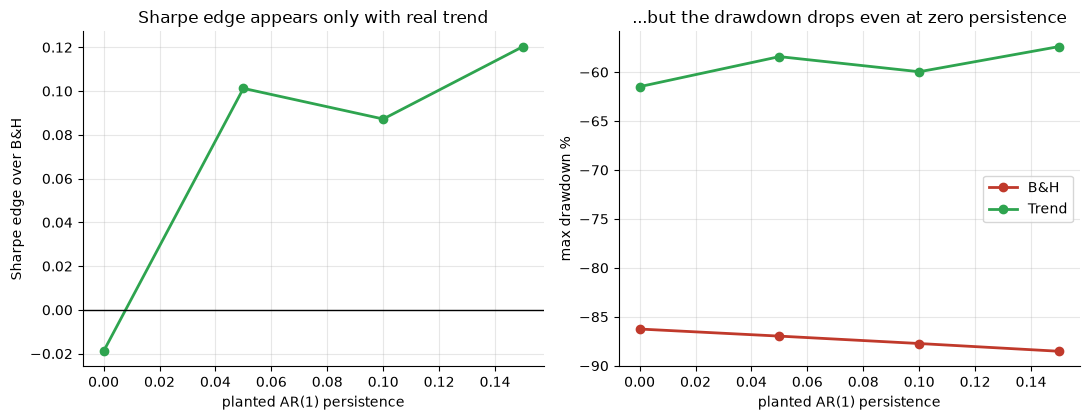

 trend_strength  BH_Sh  Trend_Sh  edge  BH_DD%  Trend_DD%
           0.00   0.40      0.38 -0.02  -86.25     -61.49
           0.05   0.41      0.51  0.10  -86.97     -58.42
           0.10   0.42      0.51  0.09  -87.73     -59.97
           0.15   0.43      0.55  0.12  -88.52     -57.39


In [6]:
rows = []
for ts in [0.0, 0.05, 0.10, 0.15]:
    b, _ = data.synthetic_theme(n_days=4000, trend_strength=ts, seed=302)
    sig = st.trend_signal(b, 200); bt = st.backtest(b, sig, cost_bps=10.0)
    bh_sh = st.sharpe(bt['asset_ret'].to_numpy()); tr_sh = st.sharpe(bt['strat_net'].to_numpy())
    bh_dd = st.max_drawdown(bt['asset_ret'].to_numpy())*100
    tr_dd = st.max_drawdown(bt['strat_net'].to_numpy())*100
    rows.append((ts, bh_sh, tr_sh, tr_sh - bh_sh, bh_dd, tr_dd))
syn = pd.DataFrame(rows, columns=['trend_strength','BH_Sh','Trend_Sh','edge','BH_DD%','Trend_DD%'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.plot(syn['trend_strength'], syn['edge'], 'o-', c=GREEN, lw=2)
a1.axhline(0, c='k', lw=1); a1.set_xlabel('planted AR(1) persistence')
a1.set_ylabel('Sharpe edge over B&H'); a1.set_title('Sharpe edge appears only with real trend')
a2.plot(syn['trend_strength'], syn['BH_DD%'], 'o-', c=RED, lw=2, label='B&H')
a2.plot(syn['trend_strength'], syn['Trend_DD%'], 'o-', c=GREEN, lw=2, label='Trend')
a2.set_xlabel('planted AR(1) persistence'); a2.set_ylabel('max drawdown %'); a2.legend()
a2.set_title('...but the drawdown drops even at zero persistence')
plt.tight_layout(); plt.show()
print(syn.round(2).to_string(index=False))

The Sharpe edge over buy-and-hold is ~0 at the random walk and grows with planted persistence — so the engine is a faithful detector, and the real-tape Sharpe edge is a statement about the theme having *some* persistence. But the drawdown reduction is present at **zero** persistence too: it is a mechanical property of being out of the market during declines, not evidence of skill. That single chart is the whole misattribution.

For the same rule on broad indices see [Study 116 — Faber-Timing](../../116-faber-timing/); for trend across many markets (where diversification rescues a thin sleeve), [Study 20 — Freight-Train](../../20-freight-train/) and [Study 31 — Trade-Winds](../../31-trade-winds/).